# Black–Litterman Model — Posterior Expected Returns

This notebook combines:

- the **equilibrium prior** expected returns $ \pi $,
- the covariance matrix $ \Sigma $,
- the view objects $(P, Q, \Omega)$,

to compute the **Black–Litterman posterior expected returns**.

We use the standard formulation with a scalar parameter $ \tau $ that scales
the uncertainty of the prior. The posterior expected returns are:

$ \mu_{\text{BL}} =
\Big( (\tau \Sigma)^{-1} + P^T \Omega^{-1} P \Big)^{-1}
\Big( (\tau \Sigma)^{-1} \pi + P^T \Omega^{-1} Q \Big) $

This notebook focuses only on:

- recomputing $ \pi $ and $ \Sigma $ for a small equity universe,
- defining $ P, Q, \Omega $ exactly as in the views notebook,
- computing the posterior mean $ \mu_{\text{BL}} $,
- comparing prior vs posterior expected returns.

No portfolio optimization or backtesting is done here.


/tmp/ipython-input-1134912251.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


<Figure size 800x500 with 0 Axes>

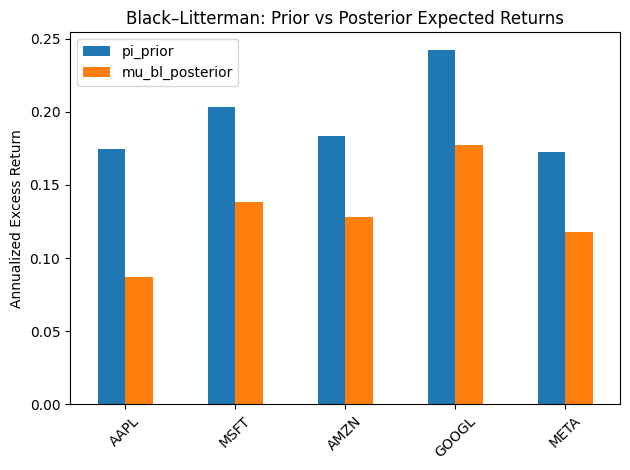

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Asset universe (must match Notebooks 1 and 2)
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
n_assets = len(tickers)

tickers, n_assets
start_date = "2018-01-01"
end_date = None  # latest available

data = yf.download(tickers, start=start_date, end=end_date)

prices = data["Close"].dropna(how="all")

# Log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Covariance matrix (annualized)
trading_days = 252
cov_daily = returns.cov()
cov_annual = cov_daily * trading_days

cov_annual
# Market portfolio weights: equal weights as a simple proxy
w_mkt = np.ones(n_assets) / n_assets
w_vec = w_mkt.reshape(-1, 1)

# Risk aversion parameter
lam = 2.5

# Implied equilibrium excess returns: π = λ Σ w_mkt
Sigma = cov_annual.values  # (n_assets x n_assets)
pi = lam * Sigma @ w_vec   # (n_assets x 1)

pi_series = pd.Series(pi.flatten(), index=tickers, name="pi_prior")
pi_series
# View matrix P (2 views x 5 assets)
# View 1: absolute view on AAPL -> [1, 0, 0, 0, 0]
# View 2: relative view MSFT - META -> [0, 1, 0, 0, -1]

P = np.array([
    [1, 0, 0, 0, 0],    # AAPL absolute view
    [0, 1, 0, 0, -1]    # MSFT relative to META
], dtype=float)

P.shape, P
# View vector Q (targets for each view, annualized excess returns)
# View 1: AAPL ≈ 8% excess return
# View 2: MSFT - META ≈ 2% excess return

Q = np.array([
    0.08,   # AAPL level
    0.02    # MSFT - META spread
], dtype=float).reshape(-1, 1)

Q.shape, Q
# View uncertainty matrix Ω
# Larger variance -> lower confidence, smaller variance -> higher confidence.

view_std_abs = 0.02   # 2% std dev for AAPL absolute view
view_std_rel = 0.01   # 1% std dev for MSFT - META spread

Omega = np.diag([
    view_std_abs**2,
    view_std_rel**2
])

Omega.shape, Omega
# Tau parameter: scales the uncertainty of the prior
tau = 0.05

# Convert to matrices
pi_vec = pi_series.values.reshape(-1, 1)
Sigma_mat = Sigma
P_mat = P
Q_vec = Q
Omega_mat = Omega

# Inverses
tauSigma_inv = np.linalg.inv(tau * Sigma_mat)
Omega_inv = np.linalg.inv(Omega_mat)

# Posterior covariance (for completeness)
middle = tauSigma_inv + P_mat.T @ Omega_inv @ P_mat
middle_inv = np.linalg.inv(middle)

# Posterior mean (Black–Litterman expected returns)
mu_bl = middle_inv @ (tauSigma_inv @ pi_vec + P_mat.T @ Omega_inv @ Q_vec)

mu_bl_series = pd.Series(mu_bl.flatten(), index=tickers, name="mu_bl_posterior")
mu_bl_series
comparison = pd.concat([pi_series, mu_bl_series], axis=1)
comparison
plt.figure(figsize=(8, 5))
comparison.plot(kind="bar")
plt.ylabel("Annualized Excess Return")
plt.title("Black–Litterman: Prior vs Posterior Expected Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Interpretation of Black–Litterman posterior

- `pi_prior` shows the **implied equilibrium excess returns** that make the
  chosen market portfolio (equal weights here) optimal under mean–variance
  assumptions.

- `mu_bl_posterior` shows the **Black–Litterman posterior expected returns**,
  obtained by combining:
  - the equilibrium prior,
  - the views encoded in $P$ and $Q$,
  - the view uncertainty specified in $Ω$,
  - the prior uncertainty level set by $τ$.

Key points:

- Assets directly involved in views (AAPL, MSFT, META) are adjusted more
  strongly than others.
- If a view has **high confidence** (small variance in $Ω$), the posterior
  will move further away from the prior for the affected linear combination.
- If views are very uncertain or $τ$ is large (weak prior precision), the
  posterior stays closer to the original equilibrium vector $π$.

This notebook stops at the level of **expected returns**. These posterior
returns can be used as inputs to a standard mean–variance optimizer in a
separate allocation or backtesting notebook.
